# Notebook 02 — Preparação para Modelagem

Parte da base tratada produzida no notebook 01 e a prepara para os modelos:
separação por finalidade, divisão treino/teste, transformações e encoding. O
princípio que rege esta fase é a **prevenção de vazamento (leakage)**: a divisão
treino/teste é feita logo no início, e toda transformação que aprende algo dos
dados (estatísticas, parâmetros de encoding) será ajustada **apenas no treino**.

In [1]:
import pandas as pd

df = pd.read_parquet("data/processed/imoveis_tratados.parquet")

print("Base tratada carregada:", df.shape)
df.info()

Base tratada carregada: (12759, 16)
<class 'pandas.DataFrame'>
Index: 12759 entries, 0 to 13639
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             12759 non-null  int64  
 1   Condo             10872 non-null  float64
 2   Size              12759 non-null  int64  
 3   Rooms             12759 non-null  int64  
 4   Toilets           12759 non-null  int64  
 5   Suites            12759 non-null  int64  
 6   Parking           12759 non-null  int64  
 7   Elevator          12759 non-null  int64  
 8   Furnished         12759 non-null  int64  
 9   Swimming Pool     12759 non-null  int64  
 10  New               12759 non-null  int64  
 11  District          12759 non-null  str    
 12  Negotiation Type  12759 non-null  str    
 13  Property Type     12759 non-null  str    
 14  Latitude          12759 non-null  float64
 15  Longitude         12759 non-null  float64
dtypes: float64(3), int64

In [2]:
# Separa a base de dados tratada entre as finalidades de venda e locação
df_venda = df[df["Negotiation Type"] == "sale"].copy()
df_aluguel = df[df["Negotiation Type"] == "rent"].copy()

print("Venda:  ", df_venda.shape)
print("Aluguel:", df_aluguel.shape)
print("Soma:   ", len(df_venda) + len(df_aluguel))

Venda:   (6014, 16)
Aluguel: (6745, 16)
Soma:    12759


## 1. Divisão treino/teste

Antes de qualquer transformação, separamos cada base (venda e aluguel) em treino e
teste. Esta ordem é deliberada e inegociável: tudo que o modelo aprende — incluindo
estatísticas de imputação, parâmetros de encoding e o spatial lag — será calculado
**somente no treino** e aplicado ao teste. O conjunto de teste representa imóveis
"futuros", nunca vistos pelo processo de modelagem; deixá-lo influenciar qualquer
etapa do aprendizado seria vazamento (leakage), inflando artificialmente o
desempenho e mascarando como o modelo se comportaria na realidade.

Usamos divisão de 80% treino / 20% teste, com seed fixa para reprodutibilidade.

In [3]:
from sklearn.model_selection import train_test_split

# Separa as features (X) do alvo (y) em cada base.

def separar_treino_teste(dados, nome):
    X = dados.drop(columns="Price")   # tudo, menos o alvo
    y = dados["Price"]                # o alvo
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,      # 20% para teste
        random_state=42      # semente fixa: a divisão é sempre a mesma
    )
    print(f"{nome:8} → treino: {X_train.shape[0]:>5} | teste: {X_test.shape[0]:>5}")
    return X_train, X_test, y_train, y_test

X_train_venda, X_test_venda, y_train_venda, y_test_venda = separar_treino_teste(df_venda, "Venda")
X_train_alug,  X_test_alug,  y_train_alug,  y_test_alug  = separar_treino_teste(df_aluguel, "Aluguel")

Venda    → treino:  4811 | teste:  1203
Aluguel  → treino:  5396 | teste:  1349


Cada base foi dividida em 80% treino / 20% teste com semente fixa (`random_state=42`),
garantindo que a divisão seja idêntica a cada execução. A partir daqui, **o conjunto
de teste fica intocado** até a avaliação final dos modelos: nenhuma estatística,
transformação ou decisão de modelagem o consultará. Toda a preparação a seguir é
ajustada sobre o treino e apenas aplicada ao teste.

## 2. Definição do conjunto de variáveis (candidato de partida)

Antes de transformar qualquer coluna, fixamos quais variáveis entram no modelo, por
quê, e quais ficam de fora. Esta é a primeira de três decisões de variáveis no
projeto: aqui definimos o **conjunto candidato de partida** (o que a base já oferece);
as variáveis espaciais e socioeconômicas serão **criadas** na Fase 3; e o conjunto
**final** será decantado empiricamente na modelagem (via VIF e importância de
features). Esta decisão é estrutural e baseada em domínio — não consulta o conjunto
de teste —, portanto não viola a regra anti-leakage.

**Alvo:** `log(Price)`. A relação hedônica é multiplicativa e o preço tem forte
assimetria à direita (média ≫ mediana, vista na auditoria); o log lineariza a relação
e normaliza os resíduos, como a NBR 14653 pressupõe.

**Atributos físicos:**
- `log(Size)` — logado pelo mesmo motivo do preço: em log-log, o coeficiente vira uma
  **elasticidade** (1% a mais de área → β% a mais de preço), forma funcional correta
  do preço hedônico, com retorno marginal decrescente por m². A área também é tão
  assimétrica quanto o preço.
- `Rooms`, `Toilets`, `Suites`, `Parking` — contagens, entram diretas. Atenção
  registrada: são correlacionadas entre si (risco de multicolinearidade), a ser
  checado por VIF na modelagem.

**Comodidades / binárias:** `Elevator`, `Furnished`, `Swimming Pool`, `New`. Entram
como 0/1. Ressalva: `New` (97–99% zero) e `Furnished` têm variância baixíssima —
candidatas a sair se não contribuírem.

**Localização (baseline):** `District` → dummies (one-hot). Captura o nível médio de
preço por bairro. É a localização "grossa"; a localização fina (spatial lag,
distância, socioeconômico) será adicionada na Fase 3, permitindo medir o ganho do
tratamento espacial sobre este baseline.

**Fora do modelo:**
- `Condo` — descartado por três razões: (1) ~15% de valores ausentes; (2) risco de
  multicolinearidade com `Swimming Pool`, academia e quadra, que preferimos manter por
  estarem completas; (3) o missing é provavelmente **não-aleatório** — comodidades
  costumam ser divulgadas, mas condomínio alto em reais tende a ser omitido no
  anúncio, então o próprio `NaN` carrega viés, e imputá-lo distorceria. Aposta
  assumida: piscina/academia/quadra capturam o sinal de qualidade que o condomínio
  traria.
- `Property Type` — constante (100% apartamentos), sem poder explicativo.
- `Negotiation Type` — é o critério de separação das duas bases, não uma feature.
- `Latitude` / `Longitude` crus — não entram diretamente; são **insumo** para as
  features espaciais da Fase 3.

## 3. Transformação logarítmica de `Price` e `Size`

Aplicamos `log` ao alvo (`Price`) e à área (`Size`), pelos motivos definidos na seção
de variáveis: lineariza a relação multiplicativa do preço hedônico, transforma o
coeficiente da área em elasticidade (log-log), e normaliza a assimetria à direita de
ambas as distribuições.

O log é uma transformação **que não aprende nada dos dados** (é uma função fixa, não
um parâmetro estimado da amostra), portanto é segura aplicar a treino e teste sem
risco de vazamento — diferente da imputação e do encoding adiante. Usamos `np.log1p`
(calcula `log(1+x)`) em vez de `np.log` por robustez a eventuais zeros; o inverso,
para reverter previsões a reais, é `np.expm1`.

In [4]:
import numpy as np

# Aplica log1p ao alvo (y) de cada conjunto — treino e teste, das duas bases.
y_train_venda_log = np.log1p(y_train_venda)
y_test_venda_log  = np.log1p(y_test_venda)
y_train_alug_log  = np.log1p(y_train_alug)
y_test_alug_log   = np.log1p(y_test_alug)

# Aplica log1p à coluna Size dentro de cada X.
# Criamos uma coluna nova 'log_Size' e removemos a 'Size' original,
for X in [X_train_venda, X_test_venda, X_train_alug, X_test_alug]:
    X["log_Size"] = np.log1p(X["Size"])
    X.drop(columns="Size", inplace=True)

print("Preço de venda — original vs log (treino):")
print(f"  média/mediana original: {y_train_venda.mean():,.0f} / {y_train_venda.median():,.0f}")
print(f"  média/mediana log:      {y_train_venda_log.mean():.2f} / {y_train_venda_log.median():.2f}")

Preço de venda — original vs log (treino):
  média/mediana original: 617,926 / 390,000
  média/mediana log:      13.00 / 12.87


A transformação simetrizou as distribuições como esperado. No preço de venda
(treino), média e mediana originais distavam ~58% (R$ 617.926 vs R$ 390.000); após o
log, ficaram praticamente coladas (13,00 vs 12,87). Média ≈ mediana confirma a
simetria, validando empiricamente a decisão de modelar em log, assim a cauda à direita
diagnosticada na auditoria foi controlada. As versões em reais (`y_*`) e em log
(`y_*_log`) ficam ambas disponíveis: treina-se em log, avalia-se em reais (o MAPE é
calculado sobre valores monetários).

## 4. Encoding do `District` (one-hot)

`District` é a única variável categórica do conjunto. Transformamo-la em variáveis
dummy (one-hot): cada bairro vira uma coluna 0/1, e seu coeficiente na regressão será
o efeito médio daquele bairro sobre o preço. Escolhemos one-hot por ser a opção que
**não usa o alvo** para construir a feature — diferente do target encoding (média de
preço por bairro), que vazaria o teste no treino.

Este é o **primeiro tratamento que aprende dos dados**: o "vocabulário" de bairros é
aprendido no treino e aplicado ao teste. Por isso usamos o `OneHotEncoder` do
scikit-learn, ajustado (`fit`) só no treino — formalizando o ritual treino→teste que
até aqui era teoria.

**Limitação assumida (baseline):** um bairro que não exista no treino (raro caído só
no teste, ou novo na produção) não terá coluna. Configuramos o encoder para ignorá-lo
(`handle_unknown='ignore'`), tratando-o como bairro neutro. É frágil de propósito —
o baseline é o marco-zero comparativo, não o modelo de produto; o tratamento robusto
da localização virá pela geografia contínua (spatial lag) na Fase 3.

In [5]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

def encodar_district(X_train, X_test):
    # Cria o encoder. handle_unknown='ignore' = bairro não visto vira tudo-zero.
    # sparse_output=False faz ele devolver um array comum (mais fácil de inspecionar).
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    # FIT só no treino: aprende o vocabulário de bairros a partir do treino.
    encoder.fit(X_train[["District"]])

    # TRANSFORM em ambos, usando o vocabulário do treino.
    train_encoded = encoder.transform(X_train[["District"]])
    test_encoded  = encoder.transform(X_test[["District"]])

    # Os nomes das novas colunas (District_Moema, District_Itaim, ...)
    nomes = encoder.get_feature_names_out(["District"])

    # Converte os arrays de volta em DataFrames, preservando o índice original
    train_df = pd.DataFrame(train_encoded, columns=nomes, index=X_train.index)
    test_df  = pd.DataFrame(test_encoded,  columns=nomes, index=X_test.index)

    # Junta as dummies ao X e remove a coluna District original de texto
    X_train_out = pd.concat([X_train.drop(columns="District"), train_df], axis=1)
    X_test_out  = pd.concat([X_test.drop(columns="District"),  test_df],  axis=1)

    print(f"Bairros no vocabulário (treino): {len(nomes)}")
    print(f"Colunas finais — treino: {X_train_out.shape[1]} | teste: {X_test_out.shape[1]}")
    return X_train_out, X_test_out

# Aplica nas duas bases
X_train_venda, X_test_venda = encodar_district(X_train_venda, X_test_venda)
X_train_alug,  X_test_alug  = encodar_district(X_train_alug,  X_test_alug)

Bairros no vocabulário (treino): 96
Colunas finais — treino: 110 | teste: 110
Bairros no vocabulário (treino): 94
Colunas finais — treino: 108 | teste: 108


O encoding produziu vocabulários de 96 bairros (venda) e 94 (aluguel), e — o ponto
crítico — treino e teste terminaram com o mesmo número de colunas em ambas as bases
(110 e 108). Essa simetria confirma que o ritual `fit`-no-treino + `handle_unknown=
'ignore'` funcionou: bairros raros caídos apenas no teste foram absorvidos como
tudo-zero, sem quebrar o alinhamento. A diferença de vocabulário entre venda (96) e
aluguel (94) mostra que as duas finalidades não cobrem exatamente os mesmos bairros, mais uma evidência a favor de modelá-las separadamente.

## 5. Limpeza final da matriz de features

Antes de modelar, removemos as colunas que não são features: `Negotiation Type`
(critério de separação das bases), `Property Type` (constante — 100% apartamentos) e
`Condo` (descartado na seção 2 por missing não-aleatório e risco de
multicolinearidade). Confirmamos que a matriz ficou inteiramente numérica e **sem
valores ausentes** — pré-requisito para os modelos, que não toleram `NaN`.

In [6]:
# Remove colunas que não são features
colunas_fora = ["Negotiation Type", "Property Type", "Condo"]

for X in [X_train_venda, X_test_venda, X_train_alug, X_test_alug]:
    X.drop(columns=colunas_fora, inplace=True)

# Conferência: sem texto e sem NaN
print("Tipos restantes (venda treino):")
print(X_train_venda.dtypes.value_counts())
print("Alguma coluna de texto?", (X_train_venda.dtypes == "object").any())
print("Algum NaN na matriz?", X_train_venda.isna().any().any())

Tipos restantes (venda treino):
float64    99
int64       8
Name: count, dtype: int64
Alguma coluna de texto? False
Algum NaN na matriz? False


A limpeza removeu as colunas não-features, deixando a matriz inteiramente numérica
(100 `float64` + 8 `int64`, sem texto). As 8 inteiras são os atributos de contagem e
binários; as float são as 96 dummies de bairro, `log_Size`, `Latitude` e `Longitude`.
O treino de venda tem 4.811 imóveis (80% de 6.014), com o teste reservado e intocado.

Com isso, a **Fase 2 (preparação) está completa**: base separada por finalidade,
dividida em treino/teste antes de qualquer transformação, alvo e área logados,
`District` codificado via one-hot ajustado só no treino, e matriz final limpa. Os
dados estão

## 6. Remoção de Latitude/Longitude do baseline

Removemos `Latitude` e `Longitude` da matriz do baseline. Justificativa: coordenadas
cruas não têm relação linear com o preço (latitude não é "quanto mais ao sul, mais
caro"), então em uma regressão linear tendem a ruído. No baseline, a localização fica
inteiramente a cargo do `District` (tratamento categórico). As coordenadas voltam na
Fase 3 como insumo das features espaciais (distância a estações, spatial lag), onde
a geografia entra de forma adequada — permitindo medir o ganho da localização fina
sobre o baseline categórico.

In [7]:
coords = ["Latitude", "Longitude"]

for X in [X_train_venda, X_test_venda, X_train_alug, X_test_alug]:
    X.drop(columns=coords, inplace=True)

print("Shape do baseline — venda treino:", X_train_venda.shape)
print("Shape do baseline — aluguel treino:", X_train_alug.shape)

Shape do baseline — venda treino: (4811, 105)
Shape do baseline — aluguel treino: (5396, 103)


## 7. Regressão linear múltipla — baseline (modelo de venda)

Primeiro modelo do projeto: regressão linear múltipla sobre os atributos físicos do
imóvel e o bairro (one-hot), com `log(Price)` como alvo. É o baseline normativo — a
abordagem que a NBR 14653 consagra —, contra o qual mediremos o ganho das features
espaciais e dos modelos de ML. Treinamos no conjunto de treino e avaliamos no teste,
que permaneceu intocado desde o split.

Métrica primária: **MAPE**, calculado em **reais** (não em log). O modelo prevê
`log(preço)`; revertemos a previsão com `expm1` antes de medir o erro, porque um erro
percentual em log não corresponde ao erro percentual em reais.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
import numpy as np

# 1. Criar e treinar o modelo (no conjunto de treino, com o alvo em LOG)
modelo_venda = LinearRegression()
modelo_venda.fit(X_train_venda, y_train_venda_log)

# 2. Prever no teste — a saída vem em LOG (porque treinamos em log)
pred_venda_log = modelo_venda.predict(X_test_venda)

# 3. Reverter a previsão para REAIS antes de avaliar
pred_venda_reais = np.expm1(pred_venda_log)

# 4. Avaliar em reais: comparamos a previsão (reais) com o alvo real (reais)
mape = mean_absolute_percentage_error(y_test_venda, pred_venda_reais)
mae  = mean_absolute_error(y_test_venda, pred_venda_reais)
r2   = r2_score(y_test_venda, pred_venda_reais)

print("=== Baseline — Venda ===")
print(f"MAPE: {mape:.1%}")
print(f"MAE:  R$ {mae:,.0f}")
print(f"R²:   {r2:.3f}")

=== Baseline — Venda ===
MAPE: 16.5%
MAE:  R$ 107,226
R²:   0.893


### Resultado do baseline — venda

| Métrica | Valor | Leitura |
|---------|-------|---------|
| **MAPE** | 16,5% | Erro percentual típico — dentro da faixa esperada (15–25%), na ponta boa. Supera os ~25% de Nova Friburgo e ~21% de Fortaleza (estudos comparáveis). |
| **MAE** | R$ 107.226 | Erro absoluto médio, inflado pela cauda de imóveis de milhões — por isso o MAPE é a métrica primária. |
| **R²** | 0,893 | Explica ~89% da variação; bem acima do 0,70 de referência da NBR. |

Um baseline forte com apenas atributos físicos + bairro (one-hot), sem nenhuma feature
espacial. Confirma o consenso da literatura: área e localização carregam a maior parte
do sinal. Este é o **marco-zero** contra o qual mediremos o ganho das features
espaciais, do bloco socioeconômico e dos modelos de ML.

## 8. Regressão linear múltipla — baseline (modelo de aluguel)

Repetimos o baseline para a locação, com a mesma estrutura do modelo de venda:
regressão linear múltipla sobre atributos físicos + bairro (one-hot), alvo em
`log(Price)`, treino no conjunto de treino e avaliação no teste reservado. As métricas
são calculadas em reais (revertendo a previsão com `expm1`), com o MAPE como primária.

Por se tratar de um mercado distinto — aluguel mensal, não valor de compra —, espera-se
que o nível dos coeficientes seja diferente do de venda; a comparação entre os dois
modelos (e, mais adiante, entre seus coeficientes) é um dos resultados de interesse do
projeto.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
import numpy as np

# 1. Criar e treinar o modelo (no conjunto de treino, com o alvo em LOG)
modelo_aluguel = LinearRegression()
modelo_aluguel.fit(X_train_alug, y_train_alug_log)

# 2. Prever no teste — a saída vem em LOG (porque treinamos em log)
pred_aluguel_log = modelo_aluguel.predict(X_test_alug)

# 3. Reverter a previsão para REAIS antes de avaliar
pred_aluguel_reais = np.expm1(pred_aluguel_log)

# 4. Avaliar em reais: comparamos a previsão (reais) com o alvo real (reais)
mape = mean_absolute_percentage_error(y_test_alug, pred_aluguel_reais)
mae  = mean_absolute_error(y_test_alug, pred_aluguel_reais)
r2   = r2_score(y_test_alug, pred_aluguel_reais)

print("=== Baseline — Aluguel ===")
print(f"MAPE: {mape:.1%}")
print(f"MAE:  R$ {mae:,.0f}")
print(f"R²:   {r2:.3f}")

=== Baseline — Aluguel ===
MAPE: 22.4%
MAE:  R$ 788
R²:   0.763


### Resultado do baseline — aluguel

| Métrica | Aluguel | Venda (ref.) | Leitura |
|---------|---------|--------------|---------|
| **MAPE** | 22,4% | 16,5% | Aluguel ~6 p.p. mais difícil de prever — padrão da literatura (mercado de locação tem mais ruído). |
| **MAE** | R$ 788 | R$ 107.226 | Escalas distintas; o MAE não compara os dois mercados (R$ 788 sobre aluguel de ~R$ 2.000 é proporcionalmente maior). |
| **R²** | 0,763 | 0,893 | Explica 76% da variação — acima do 0,70 da NBR, mas abaixo da venda: os atributos determinam menos o aluguel. |

Confirma-se o esperado: locação é mais difícil de modelar que venda com os mesmos
atributos, por carregar mais ruído não capturado pela base (mobília, reajustes,
negociação informal). A comparação válida entre os mercados é por MAPE (percentual),
não por MAE (escala absoluta diferente).

## 9. Diagnósticos do baseline (modelo de venda)

A regressão linear da tradição NBR não se valida só pela acurácia preditiva — exige
verificar os pressupostos do modelo. Rodamos três diagnósticos sobre o baseline de
venda: multicolinearidade (VIF), normalidade dos resíduos e homocedasticidade.

### 9.1 Multicolinearidade — VIF

O VIF (Variance Inflation Factor) mede quanto a variância de cada coeficiente é
inflada pela correlação daquela variável com as demais. Regra prática usual: VIF até 5
é tranquilo, entre 5 e 10 é zona de atenção, acima de 10 indica multicolinearidade
séria. Interessa-nos especialmente o bloco de atributos de tamanho (`Rooms`,
`Toilets`, `Suites`, `log_Size`), que a auditoria já sinalizou como correlacionados.
Calculamos o VIF apenas sobre as variáveis contínuas/de contagem — as 96 dummies de
bairro são, por construção, mutuamente exclusivas e seu VIF não é informativo aqui.

In [10]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# O VIF interessa nas features de atributo, não nas 96 dummies de bairro.
# Selecionamos só as colunas que NÃO são de bairro (não começam com "District_").
features_atributo = [c for c in X_train_venda.columns if not c.startswith("District_")]
X_vif = X_train_venda[features_atributo].copy()

# add_constant adiciona o intercepto — o VIF precisa dele para o cálculo correto
X_vif = add_constant(X_vif)

# Calcula o VIF de cada variável
vif = pd.DataFrame()
vif["variavel"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Mostra ordenado do maior para o menor (ignorando a constante)
print(vif[vif["variavel"] != "const"].sort_values("VIF", ascending=False).to_string(index=False))

     variavel      VIF
      Toilets 5.714937
       Suites 5.156986
     log_Size 3.380775
      Parking 2.626783
        Rooms 2.337980
Swimming Pool 1.186722
     Elevator 1.183944
          New 1.068305
    Furnished 1.026029


**Resultado (VIF):** o bloco de tamanho mostra multicolinearidade *moderada*, não
severa. `Toilets` (5,71) e `Suites` (5,16) ficam logo acima de 5 (zona de atenção,
não crítica); `log_Size` (3,38), `Parking` (2,63) e `Rooms` (2,34) estão confortáveis;
as binárias, próximas de 1.

**Decisão:** nenhuma ação corretiva. VIFs na casa de 5–6 são toleráveis para um modelo
voltado à previsão (AVM-produto). Registra-se a limitação: os coeficientes de
`Toilets` e `Suites`, isoladamente, devem ser interpretados com cautela — não são
medidas causais limpas do efeito de cada um. Num laudo NBR formal, onde a
interpretação de coeficientes tem peso, valeria agrupar ou remover um deles.

### 9.2 Normalidade dos resíduos

A regressão linear clássica assume que os resíduos (as diferenças entre preço real e
previsto, em log) seguem uma distribuição normal. É um dos pressupostos que a NBR
14653 cobra, e sustenta a validade dos testes t e dos intervalos de confiança dos
coeficientes. Verificamos de duas formas: o **Q-Q plot** (inspeção visual da forma do
desvio) e o teste de **Shapiro-Francia / Shapiro-Wilk** (avaliação formal). Os
resíduos são calculados sobre o conjunto de treino, em log — o espaço em que o modelo
foi ajustado.

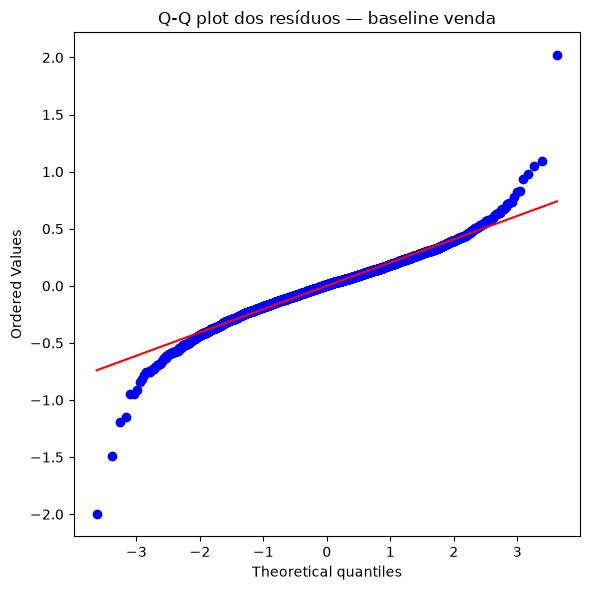

Shapiro-Wilk — estatística: 0.9654 | p-valor: 1.6741e-32


In [11]:
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt

# Reajusta o baseline de venda via statsmodels (precisa do intercepto explícito)
X_train_sm = sm.add_constant(X_train_venda)
modelo_sm = sm.OLS(y_train_venda_log, X_train_sm).fit()

# Os resíduos: diferença entre o log(preço) real e o previsto, no treino
residuos = modelo_sm.resid

# --- Q-Q plot: compara a distribuição dos resíduos com a normal teórica ---
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuos, dist="norm", plot=ax)
ax.set_title("Q-Q plot dos resíduos — baseline venda")
plt.tight_layout()
plt.show()

# --- Teste formal de normalidade ---
# Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"Shapiro-Wilk — estatística: {shapiro_stat:.4f} | p-valor: {shapiro_p:.4e}")

**Resultado (normalidade):** o Shapiro-Wilk dá p-valor ≈ 1,7e-32 (rejeita normalidade),
mas a estatística é 0,965 — muito próxima de 1. A discrepância é esperada: com 4.811
observações, o teste detecta qualquer desvio mínimo da normal e rejeita quase sempre,
então a estatística e o gráfico são mais informativos que o p-valor.

O Q-Q plot mostra um "S" característico: o miolo dos resíduos segue a reta (normal),
mas as duas pontas abrem — caudas pesadas (leptocurtose). O modelo erra mais nos
extremos do que uma normal previria, subestimando imóveis muito caros (cauda superior)
e superestimando os muito baratos (cauda inferior). São os imóveis de luxo
(R$ 7–10 mi) e de periferia (R$ ~60 mil) identificados na auditoria, cujo preço
depende de fatores que os atributos físicos + bairro não capturam.

**Avaliação:** desvio moderado e localizado nas caudas, não no centro. Para um
AVM-produto, é tolerável — o modelo é confiável no grosso do mercado e menos preciso
nos extremos, o que é honesto declarar. O log já mitigou a assimetria original; o
resíduo restante reflete a heterogeneidade intrínseca das pontas do mercado.

### 9.3 Homocedasticidade

O último pressuposto: a variância dos resíduos deve ser constante ao longo dos valores
previstos (homocedasticidade). Se a dispersão dos erros cresce ou diminui conforme o
preço (heterocedasticidade), os intervalos de confiança e os testes t dos coeficientes
ficam enviesados — embora a previsão pontual não seja invalidada. Verificamos de duas
formas: o **gráfico de resíduos vs. valores previstos** (inspeção visual) e o teste
formal de **Breusch-Pagan**.

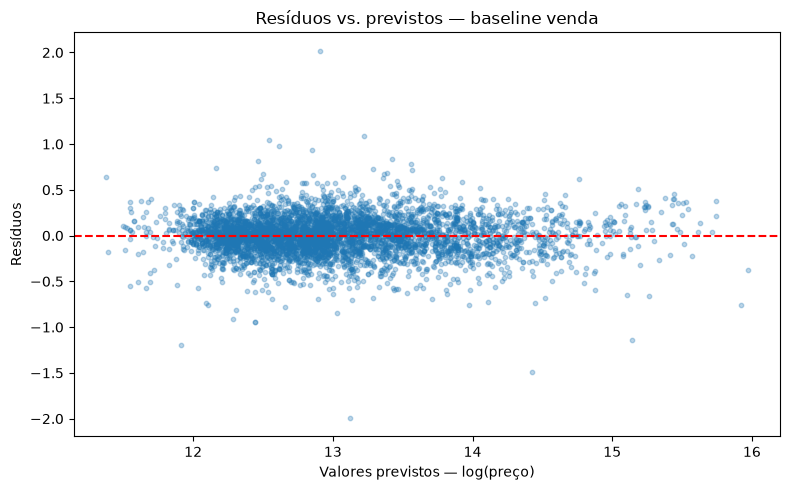

Breusch-Pagan — estatística LM: 271.81 | p-valor: 9.8839e-17


In [12]:
import statsmodels.stats.api as sms
import matplotlib.pyplot as plt

# Valores previstos pelo modelo statsmodels (em log), no treino
previstos = modelo_sm.fittedvalues

# --- Gráfico: resíduos vs. valores previstos ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(previstos, residuos, alpha=0.3, s=10)
ax.axhline(y=0, color="red", linestyle="--")
ax.set_xlabel("Valores previstos — log(preço)")
ax.set_ylabel("Resíduos")
ax.set_title("Resíduos vs. previstos — baseline venda")
plt.tight_layout()
plt.show()

# --- Teste formal de Breusch-Pagan ---
bp_stat, bp_p, _, _ = sms.het_breuschpagan(residuos, X_train_sm)
print(f"Breusch-Pagan — estatística LM: {bp_stat:.2f} | p-valor: {bp_p:.4e}")

**Resultado (homocedasticidade):** o Breusch-Pagan dá p-valor ≈ 9,9e-17, rejeitando a
homocedasticidade — mas, como nos diagnósticos anteriores, o tamanho da amostra e os
outliers tornam o teste formal sensível demais; o gráfico é mais informativo.

O gráfico de resíduos vs. previstos mostra uma nuvem aproximadamente constante (um
"tubo" centrado no zero), não um funil. À direita (imóveis mais caros) os pontos
ficam mais ralos — reflexo da menor quantidade de imóveis nessas faixas, não de maior
dispersão dos erros. Há outliers espalhados por toda a extensão (não concentrados numa
ponta), que respondem pela rejeição formal. O log do preço, aplicado na preparação, já
neutralizou a heterocedasticidade severa que o preço bruto apresentaria.

**Avaliação:** heterocedasticidade leve e difusa, sem padrão de funil. Para um
AVM-produto focado em previsão, não compromete o uso; a ressalva recai sobre a
interpretação fina dos intervalos de confiança dos coeficientes, não sobre a predição.

### Síntese dos diagnósticos — baseline de venda

| Pressuposto | Diagnóstico | Veredito |
|-------------|-------------|----------|
| **Multicolinearidade** | VIF | Moderada em `Toilets`/`Suites` (~5); tolerável. Coeficientes desses dois a ler com cautela. |
| **Normalidade dos resíduos** | Q-Q + Shapiro | Miolo normal, caudas pesadas ("S") nos extremos de preço. Estatística 0,965 — desvio pequeno. |
| **Homocedasticidade** | Resíduos vs. previstos + Breusch-Pagan | Dispersão aproximadamente constante; sem funil. Heterocedasticidade leve. |

Os três desvios formais (VIF > 5, p-valores ínfimos) são detectados pelos testes mas,
na inspeção, revelam-se moderados e localizados — todos consequência da
heterogeneidade natural das pontas do mercado imobiliário, não de falha de
especificação. O baseline é estatisticamente válido para previsão, com as ressalvas
de interpretação registradas. Marco-zero confirmado conforme a tradição NBR 14653.

## 10. Diagnósticos do baseline (modelo de aluguel)

Repetimos a tríade de diagnósticos no modelo de aluguel, de forma resumida. O objetivo
é confirmar se os pressupostos se comportam como na venda ou se a locação — mais ruidosa
(R² 0,76 vs 0,89) — apresenta desvios mais acentuados. Lemos os três em conjunto.

=== VIF (aluguel) ===
     variavel      VIF
       Suites 6.754531
      Toilets 6.710784
     log_Size 3.805095
      Parking 2.882394
        Rooms 2.458134
Swimming Pool 1.167765
    Furnished 1.070779
     Elevator 1.064310
          New 1.002248

=== Normalidade (aluguel) ===
Shapiro: estat 0.9886 | p 1.9736e-20

=== Homocedasticidade (aluguel) ===
Breusch-Pagan: estat 491.89 | p 4.8725e-52


c:\Users\lucas\Documents\avm-sao-paulo\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5396.
  res = hypotest_fun_out(*samples, **kwds)


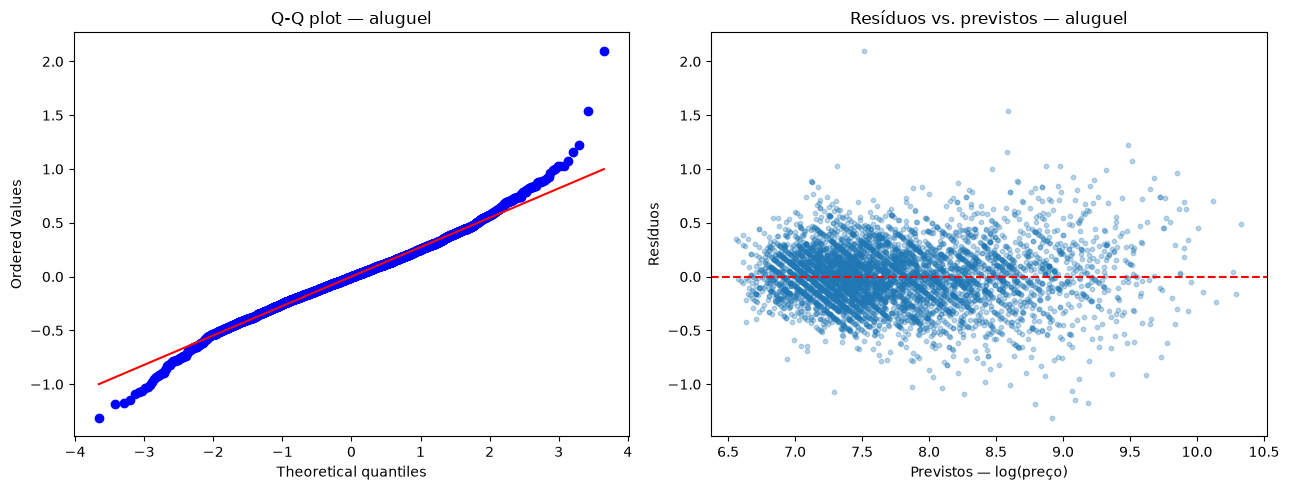

In [13]:
import statsmodels.api as sm
import statsmodels.stats.api as sms
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
import pandas as pd

# Reajusta o baseline de aluguel via statsmodels
X_train_alug_sm = sm.add_constant(X_train_alug)
modelo_alug_sm = sm.OLS(y_train_alug_log, X_train_alug_sm).fit()
residuos_alug = modelo_alug_sm.resid
previstos_alug = modelo_alug_sm.fittedvalues

# --- 1. VIF (só nos atributos, sem as dummies de bairro) ---
feats = [c for c in X_train_alug.columns if not c.startswith("District_")]
X_vif = add_constant(X_train_alug[feats].copy())
vif = pd.DataFrame({
    "variavel": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print("=== VIF (aluguel) ===")
print(vif[vif["variavel"] != "const"].sort_values("VIF", ascending=False).to_string(index=False))

# --- 2. Normalidade (Shapiro) ---
sw_stat, sw_p = stats.shapiro(residuos_alug)
print(f"\n=== Normalidade (aluguel) ===\nShapiro: estat {sw_stat:.4f} | p {sw_p:.4e}")

# --- 3. Homocedasticidade (Breusch-Pagan) ---
bp_stat, bp_p, _, _ = sms.het_breuschpagan(residuos_alug, X_train_alug_sm)
print(f"\n=== Homocedasticidade (aluguel) ===\nBreusch-Pagan: estat {bp_stat:.2f} | p {bp_p:.4e}")

# --- Gráficos lado a lado: Q-Q e resíduos vs previstos ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
stats.probplot(residuos_alug, dist="norm", plot=ax1)
ax1.set_title("Q-Q plot — aluguel")
ax2.scatter(previstos_alug, residuos_alug, alpha=0.3, s=10)
ax2.axhline(y=0, color="red", linestyle="--")
ax2.set_xlabel("Previstos — log(preço)")
ax2.set_ylabel("Resíduos")
ax2.set_title("Resíduos vs. previstos — aluguel")
plt.tight_layout()
plt.show()

### Síntese dos diagnósticos — aluguel (e comparação com venda)

| Pressuposto | Aluguel | Venda | Leitura |
|-------------|---------|-------|---------|
| **VIF** | `Suites` 6,75 / `Toilets` 6,71 | ~5,1–5,7 | Mesmo padrão (suíte ⊂ banheiro), levemente mais acentuado. Tolerável. |
| **Normalidade** | Shapiro 0,989 | 0,965 | Aluguel **mais** normal — menos cauda de luxo (não há aluguéis de milhões como há vendas). |
| **Homocedasticidade** | tubo, sem funil | tubo, sem funil | Igual. |

O aluguel confirma os mesmos pressupostos da venda, com uma diferença instrutiva: é
mais ruidoso no centro (R² 0,76 vs 0,89), mas tem caudas mais leves (resíduos mais
normais), porque seu mercado não tem extremos tão acentuados quanto o de venda.
Pressupostos validados; baseline de aluguel apto para previsão, com as mesmas
ressalvas de interpretação.

## 11. Enriquecimento espacial — Bloco 1: distância à estação mais próxima

Início da Fase 3. O primeiro bloco constrói, para cada imóvel, a distância até a
estação de metrô ou trem mais próxima — a localização de transporte é um dos
principais determinantes de preço na cidade de São Paulo. Os dados de estações vêm do GeoSampa
(portal oficial da Prefeitura), em GeoJSON.

Antes de calcular distâncias, inspecionamos os arquivos: quantas estações vieram, que
colunas têm, e — crucial — em que sistema de coordenadas estão (lat/long ou UTM). Só
depois aplicamos o filtro de contemporaneidade (manter apenas estações que já
operavam em jan/2019).

In [14]:
import geopandas as gpd

# Carrega as camadas de estações (ajuste os nomes dos arquivos conforme baixou)
metro = gpd.read_file("data/raw/estacoes_metro.geojson")
trem  = gpd.read_file("data/raw/estacoes_trem.geojson")

# Quantas estações em cada camada?
print("Estações de metrô:", len(metro))
print("Estações de trem: ", len(trem))

# Que colunas vieram? (queremos achar o NOME da estação e talvez a linha)
print("\nColunas metrô:", list(metro.columns))

# O sistema de coordenadas (CRS) — lat/long ou UTM?
print("\nCRS metrô:", metro.crs)

# As primeiras linhas, para ver a cara dos dados
metro.head()

Estações de metrô: 94
Estações de trem:  109

Colunas metrô: ['id', 'cd_identificador', 'cd_identificador_empresa_metro_trem', 'nm_estacao_metro_trem', 'cd_situacao_estacao_metro_trem', 'sg_fonte_original', 'cd_identificador_linha', 'tx_situacao_metro_trem', 'nm_linha_metro_trem', 'nm_empresa_metro_trem', 'cd_tipo_transporte', 'geometry']

CRS metrô: EPSG:31983


,id,cd_identificador,cd_identificador_empresa_metro_trem,nm_estacao_metro_trem,cd_situacao_estacao_metro_trem,sg_fonte_original,cd_identificador_linha,tx_situacao_metro_trem,nm_linha_metro_trem,nm_empresa_metro_trem,cd_tipo_transporte,geometry
0,estacao_metro_v2.1,1,1,CORINTHIANS-ITAQUERA,1,METRO,3,OPERANDO,VERMELHA,METRO,1,POINT (349839.38 7395675.047)
1,estacao_metro_v2.2,2,1,ARTUR ALVIM,1,METRO,3,OPERANDO,VERMELHA,METRO,1,POINT (348457.592 7395884.165)
2,estacao_metro_v2.3,3,1,PATRIARCA,1,METRO,3,OPERANDO,VERMELHA,METRO,1,POINT (346732.712 7396874.617)
3,estacao_metro_v2.4,4,1,GUILHERMINA-ESPERANÇA,1,METRO,3,OPERANDO,VERMELHA,METRO,1,POINT (345181.965 7397070.921)
4,estacao_metro_v2.5,5,1,VILA MATILDE,1,METRO,3,OPERANDO,VERMELHA,METRO,1,POINT (343708.935 7396765.736)


In [15]:
# 1. Quais situações existem? (pode haver estações não-operantes a remover)
print("=== Situações — metrô ===")
print(metro["tx_situacao_metro_trem"].value_counts())
print("\n=== Situações — trem ===")
print(trem["tx_situacao_metro_trem"].value_counts())

# 2. Quais linhas existem em cada camada? (guia do filtro temporal)
print("\n=== Linhas — metrô ===")
print(metro["nm_linha_metro_trem"].value_counts())
print("\n=== Linhas — trem ===")
print(trem["nm_linha_metro_trem"].value_counts())

=== Situações — metrô ===
tx_situacao_metro_trem
OPERANDO    94
Name: count, dtype: int64

=== Situações — trem ===
tx_situacao_metro_trem
OPERANDO    109
Name: count, dtype: int64

=== Linhas — metrô ===
nm_linha_metro_trem
AZUL        24
VERMELHA    18
LILAS       17
VERDE       14
AMARELA     11
PRATA       10
Name: count, dtype: int64

=== Linhas — trem ===
nm_linha_metro_trem
DIAMANTE     23
ESMERALDA    21
CORAL        17
RUBI         17
TURQUESA     15
SAFIRA       13
JADE          3
Name: count, dtype: int64


In [16]:
# Lista os nomes reais das estações nas linhas que têm remoções, como estão no GeoSampa
for linha in ["AMARELA", "LILAS", "PRATA"]:
    print(f"\n=== {linha} ===")
    nomes = metro[metro["nm_linha_metro_trem"] == linha]["nm_estacao_metro_trem"].tolist()
    for n in sorted(nomes):
        print(" ", n)

# Confere também se há linhas no arquivo além das 6 que vimos (Laranja? Ouro?)
print("\n=== Todas as linhas de metrô no arquivo ===")
print(metro["nm_linha_metro_trem"].value_counts())


=== AMARELA ===
  BUTANTÃ
  FARIA LIMA
  FRADIQUE COUTINHO
  HIGIENÓPOLIS-MACKENZIE
  LUZ
  OSCAR FREIRE
  PAULISTA
  PINHEIROS
  REPÚBLICA
  SÃO PAULO-MORUMBI
  VILA SÔNIA

=== LILAS ===
  AACD-SERVIDOR
  ADOLFO PINHEIRO
  ALTO DA BOA VISTA
  BORBA GATO
  BROOKLIN
  CAMPO BELO
  CAMPO LIMPO
  CAPÃO REDONDO
  CHÁCARA KLABIN
  EUCALIPTOS
  GIOVANNI GRONCHI
  HOSPITAL SÃO PAULO
  LARGO TREZE
  MOEMA
  SANTA CRUZ
  SANTO AMARO
  VILA DAS BELEZAS

=== PRATA ===
  CAMILO HADDAD
  FAZENDA DA JUTA
  JARDIM PLANALTO
  ORATÓRIO
  SAPOPEMBA
  SÃO LUCAS
  SÃO MATEUS
  VILA PRUDENTE
  VILA TOLSTÓI
  VILA UNIÃO

=== Todas as linhas de metrô no arquivo ===
nm_linha_metro_trem
AZUL        24
VERMELHA    18
LILAS       17
VERDE       14
AMARELA     11
PRATA       10
Name: count, dtype: int64


In [17]:
# Lista as estações de cada linha de TREM, como estão no GeoSampa
for linha in sorted(trem["nm_linha_metro_trem"].unique()):
    print(f"\n=== {linha} ===")
    nomes = trem[trem["nm_linha_metro_trem"] == linha]["nm_estacao_metro_trem"].tolist()
    for n in sorted(nomes):
        print(" ", n)


=== CORAL ===
  ANTONIO GIANETTI NETO
  BRÁS
  BRÁS CUBAS
  CALMON VIANA
  CORINTHIANS - ITAQUERA
  DOM BOSCO
  ESTUDANTES
  FERRAZ DE VASCONCELOS
  GUAIANASES
  JOSÉ BONIFÁCIO
  JUNDIAPEBA
  LUZ
  MOGI DAS CRUZES
  PALMEIRAS - BARRA FUNDA
  POÁ
  SUZANO
  TATUAPÉ

=== DIAMANTE ===
  AMADOR BUENO
  AMBUITÁ
  ANTÔNIO JOÃO
  BARUERI
  CARAPICUÍBA
  COMANDANTE SAMPAIO
  DOMINGOS DE MORAIS
  ENGENHEIRO CARDOSO
  GENERAL MIGUEL COSTA
  IMPERATRIZ LEOPOLDINA
  ITAPEVI
  JANDIRA
  JARDIM BELVAL
  JARDIM SILVEIRA
  JÚLIO PRESTES
  LAPA (LINHA 8)
  OSASCO
  PALMEIRAS - BARRA FUNDA
  PRESIDENTE ALTINO
  QUITAÚNA
  SAGRADO CORAÇÃO
  SANTA RITA
  SANTA TEREZINHA

=== ESMERALDA ===
  AUTÓDROMO
  BERRINI
  CEASA
  CIDADE JARDIM
  CIDADE UNIVERSITÁRIA
  GRAJAÚ
  GRANJA JULIETA
  HEBRAICA - REBOUÇAS
  JOÃO DIAS
  JURUBATUBA
  MENDES / BRUNO COVAS
  MORUMBI
  OSASCO
  PINHEIROS
  PRESIDENTE ALTINO
  PRIMAVERA - INTERLAGOS
  SANTO AMARO (LINHA 9)
  SOCORRO
  VARGINHA
  VILA OLÍMPIA
  VILLA-LOBOS - JAGU

### Filtro de contemporaneidade temporal

A camada do GeoSampa traz a rede atual; removemos as estações inauguradas **após
abril de 2019** (data da base de imóveis), para não atribuir aos imóveis uma amenidade
que não existia no momento do anúncio — um leakage temporal. Critério: data de
operação (fato auditável), não expectativa de abertura. Lista definida por pesquisa
das datas de inauguração, auditando **todas** as linhas de metrô e de trem.

Removidas (9): metrô — Vila Sônia (Amarela) e cinco da Prata (Jardim Planalto,
Sapopemba, Fazenda da Juta, São Mateus, Jardim Colonial); trem — três da Esmeralda
(Mendes/Bruno Covas, João Dias, Varginha). Mantidas conscientemente: Campo Belo
(Lilás, 8/abr/2019, dentro do mês da base) e estações da Prata em operação assistida
desde 2018.

In [18]:
# Estações inauguradas APÓS abril/2019 — grafia exata conforme o GeoSampa
metro_pos_corte = [
    "VILA SÔNIA",       # Amarela — dez/2021
    "JARDIM PLANALTO",  # Prata — ago/2019
    "SAPOPEMBA",        # Prata — dez/2019
    "FAZENDA DA JUTA",  # Prata — dez/2019
    "SÃO MATEUS",       # Prata — dez/2019
    "JARDIM COLONIAL",  # Prata — dez/2021
]
trem_pos_corte = [
    "MENDES / BRUNO COVAS",  # Esmeralda — ago/2021
    "JOÃO DIAS",             # Esmeralda — nov/2021
    "VARGINHA",              # Esmeralda — jan/2025
]

# Aplica o filtro em cada modalidade (~ = negação: mantém quem NÃO está na lista)
metro_2019 = metro[~metro["nm_estacao_metro_trem"].isin(metro_pos_corte)].copy()
trem_2019  = trem[~trem["nm_estacao_metro_trem"].isin(trem_pos_corte)].copy()

# Conferências: contagem e checagem de que nenhuma da lista sobrou
print(f"Metrô: {len(metro)} → {len(metro_2019)} ({len(metro) - len(metro_2019)} removidas)")
print(f"Trem:  {len(trem)} → {len(trem_2019)} ({len(trem) - len(trem_2019)} removidas)")
print("Metrô — da lista ainda presentes (deve ser 0):",
      metro_2019["nm_estacao_metro_trem"].isin(metro_pos_corte).sum())
print("Trem  — da lista ainda presentes (deve ser 0):",
      trem_2019["nm_estacao_metro_trem"].isin(trem_pos_corte).sum())

Metrô: 94 → 89 (5 removidas)
Trem:  109 → 106 (3 removidas)
Metrô — da lista ainda presentes (deve ser 0): 0
Trem  — da lista ainda presentes (deve ser 0): 0


**Resultado do filtro:** metrô 94 → 89 (5 removidas: Vila Sônia e quatro da Prata —
Jardim Planalto, Sapopemba, Fazenda da Juta, São Mateus); trem 109 → 106 (3 removidas:
Mendes/Bruno Covas, João Dias, Varginha — todas da Esmeralda). Total: **195 estações**
operantes em abril/2019.

Nota: a Jardim Colonial (Prata, dez/2021) constava da lista de remoção mas não estava
no arquivo — ela vive na camada de estações *em projeto* do GeoSampa, não na de
*operação* que baixamos. A camada de operação, por construção, já exclui o que não
opera; nosso filtro temporal tratou o complemento (estações que operam hoje mas
abriram após o corte). Os dois mecanismos se somam.

### União das modalidades e conversão de coordenadas (CRS)

Unimos as estações de metrô e trem operantes em 2019 num único conjunto (para o imóvel,
o que importa é a estação mais próxima, seja ela metrô ou trem). Em seguida convertemos
o sistema de coordenadas (CRS) de SIRGAS 2000 / UTM 23S (EPSG:31983, em metros) para
WGS 84 (EPSG:4326, latitude/longitude em graus) — o mesmo da base de imóveis. Sem
alinhar os CRS, qualquer cálculo de distância entre imóveis e estações seria sem sentido.

In [19]:
import pandas as pd
import geopandas as gpd

# Une metrô + trem num só GeoDataFrame (concatena as linhas)
estacoes = pd.concat([metro_2019, trem_2019], ignore_index=True)
print("Total de estações (metrô + trem):", len(estacoes))

# Converte de UTM (EPSG:31983) para lat/long (EPSG:4326)
estacoes = estacoes.to_crs(epsg=4326)

# Confere: a geometria agora deve estar em graus (-23, -46), não em metros
print("CRS após conversão:", estacoes.crs)
print(estacoes.geometry.head(3))

Total de estações (metrô + trem): 195
CRS após conversão: EPSG:4326
0    POINT (-46.47108 -23.54231)
1    POINT (-46.48459 -23.54029)
2    POINT (-46.50138 -23.53118)
Name: geometry, dtype: geometry


### Cálculo da distância à estação mais próxima

Para cada imóvel, calculamos a distância (em metros) até a estação mais próxima entre
as 195 operantes em 2019. Procedimento correto para distância geográfica: reprojetar
imóveis e estações para um CRS **métrico** (UTM 23S, EPSG:31983) antes de medir —
calcular distância sobre graus (lat/long) distorce, porque um grau de longitude e um
de latitude não medem o mesmo comprimento. No UTM, a distância é euclidiana honesta,
em metros.

A feature é puramente geométrica (imóvel ↔ estação), não usa o preço — portanto não há
risco de leakage. Ainda assim, calculamo-la sobre treino e teste separadamente, por
consistência de processo.

In [20]:
import geopandas as gpd

def adicionar_distancia_estacao(df, estacoes_latlong):
    """Calcula, para cada imóvel, a distância (m) até a estação mais próxima."""
    # 1. Transforma o df de imóveis em GeoDataFrame, criando a geometria a partir de lat/long
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
        crs="EPSG:4326"  # lat/long, mesmo CRS das estações já convertidas
    )

    # 2. Reprojeta imóveis E estações para UTM (métrico) para medir em metros
    gdf_utm = gdf.to_crs(epsg=31983)
    estacoes_utm = estacoes_latlong.to_crs(epsg=31983)

    # 3. Junção espacial pelo vizinho mais próximo: liga cada imóvel à estação mais perto
    #    O sjoin_nearest cria a coluna 'distancia_estacao' com a distância em metros
    juntado = gpd.sjoin_nearest(
        gdf_utm,
        estacoes_utm[["nm_estacao_metro_trem", "geometry"]],
        how="left",
        distance_col="distancia_estacao"
    )

    # 4. sjoin_nearest pode duplicar linhas em caso de empate (imóvel equidistante de 2
    #    estações). Removemos duplicatas mantendo a primeira, pelo índice original.
    juntado = juntado[~juntado.index.duplicated(keep="first")]

    # Devolve só a coluna de distância, alinhada ao índice original do df
    return juntado["distancia_estacao"]

# Calcula e adiciona a coluna em cada base
df_venda["distancia_estacao"] = adicionar_distancia_estacao(df_venda, estacoes)
df_aluguel["distancia_estacao"] = adicionar_distancia_estacao(df_aluguel, estacoes)

# Confere o resultado: estatísticas da nova feature (em metros)
print("=== Distância à estação mais próxima — venda (metros) ===")
print(df_venda["distancia_estacao"].describe().round(2))

=== Distância à estação mais próxima — venda (metros) ===
count       6014.00
mean        4246.85
std        45702.85
min           18.45
25%          583.58
50%         1171.08
75%         2143.27
max      2421468.98
Name: distancia_estacao, dtype: float64


### Leitura da distância e detecção de coordenadas corrompidas

O `describe()` da distância à estação revela duas coisas: a feature está sendo
calculada corretamente para a grande maioria dos imóveis, mas há **coordenadas
corrompidas** contaminando os extremos.

**O que está correto — os percentis (robustos a outliers):**

| Estatística | Valor | Leitura |
|-------------|-------|---------|
| mínimo | 18 m | imóvel praticamente na porta de uma estação — plausível |
| 25% | 584 m | um quarto dos imóveis a menos de ~600 m |
| mediana | 1.171 m | o imóvel típico está a ~1,2 km da estação mais próxima |
| 75% | 2.143 m | três quartos a menos de ~2,1 km |

Esses números contam uma história coerente com a geografia real de São Paulo:
boa cobertura de transporte sobre trilhos no centro expandido (onde se concentra a
maioria dos anúncios) e distâncias crescentes em direção às bordas. A mediana de
~1,2 km confirma que o cálculo geométrico (reprojeção para UTM + vizinho mais próximo)
está funcionando.

**O que está errado — média, desvio e máximo:**

| Estatística | Valor | Problema |
|-------------|-------|----------|
| máximo | 2.421.469 m | **2.421 km** — distância de SP a quase a Amazônia; fisicamente impossível |
| média | 4.247 m | inflada — muito acima da mediana (1.171 m), puxada pelos outliers |
| desvio | 45.703 m | absurdamente alto — sintoma claro de valores extremos contaminando |

Nenhum imóvel na cidade de São Paulo está a milhares de quilômetros de uma estação.
Esses valores só podem vir de **coordenadas corrompidas** — latitude/longitude com
dígito trocado ou sinal invertido que, isoladamente, parecem plausíveis (-23,xx /
-46,xx), mas apontam para um ponto distante quando usadas no cálculo.

**Por que a auditoria da Fase 1 não pegou isto:** na Fase 1 removemos coordenadas
obviamente inválidas — os pares (0, 0) e os 17 com lat/lon invertidas. Mas uma
coordenada sutilmente errada, ainda dentro da faixa de valores de SP, não dispara
alarme quando a coluna é olhada isoladamente. O erro só se revelou agora, ao **cruzar
a coordenada com um ponto de referência** (a estação) e medir a distância. Lição de
método: a auditoria de dados não termina numa fase — operações novas expõem
inconsistências novas, e a vigilância continua.

**Próximo passo:** identificar quantos imóveis têm distância implausível (corte de
50 km, generoso — nada legítimo em SP ultrapassa ~40 km de uma estação), inspecionar
suas coordenadas e `District`, e tratar antes de a distância entrar no modelo.

In [21]:
# Quantos imóveis têm distância implausível? (acima de, digamos, 50 km = 50.000 m)
limite = 50_000
suspeitos_venda = df_venda[df_venda["distancia_estacao"] > limite]
print(f"Imóveis com distância > 50 km (venda): {len(suspeitos_venda)}")

# Olha as coordenadas e a distância desses suspeitos
print(suspeitos_venda[["District", "Latitude", "Longitude", "distancia_estacao"]].to_string())

# Mesma checagem no aluguel
suspeitos_alug = df_aluguel[df_aluguel["distancia_estacao"] > limite]
print(f"\nImóveis com distância > 50 km (aluguel): {len(suspeitos_alug)}")
print(suspeitos_alug[["District", "Latitude", "Longitude", "distancia_estacao"]].to_string())

Imóveis com distância > 50 km (venda): 33
                          District   Latitude  Longitude  distancia_estacao
8226          Bom Retiro/São Paulo -26.922512 -49.060707       4.259382e+05
8308                Brás/São Paulo -26.922512 -49.060707       4.259382e+05
8552       Santa Cecília/São Paulo -22.786299 -43.305311       3.056521e+05
8805     Jardim Paulista/São Paulo  -1.364173 -48.269834       2.421469e+06
8832               Moema/São Paulo -26.922512 -49.060707       4.259382e+05
8913   Alto de Pinheiros/São Paulo -26.922512 -49.060707       4.259382e+05
8951   Alto de Pinheiros/São Paulo -26.922571 -49.060645       4.259400e+05
8992            Perdizes/São Paulo -26.922512 -49.060707       4.259382e+05
9001            Perdizes/São Paulo -26.922512 -49.060707       4.259382e+05
9055           Pinheiros/São Paulo -14.211243 -42.798304       1.080414e+06
11938        Barra Funda/São Paulo -26.922512 -49.060707       4.259382e+05
11942        Barra Funda/São Paulo -26.922512 

### Remoção de coordenadas corrompidas

Os imóveis com distância implausível (>50 km) têm coordenadas corrompidas de dois
tipos: um valor sentinela repetido (-26,92 / -49,06, em Santa Catarina — provável
fallback do geocodificador da base) e erros dispersos (Belém, Buenos Aires, interior
da BA), todos com `District` de São Paulo contradizendo a posição. Como são poucos
(~56, <0,5% da base) e a recuperação por centroide de bairro comprometeria o spatial
lag adiante (vizinhança falsa), removemos — consistente com o tratamento dado aos
(0,0) na Fase 1.

Critério de remoção: vamos iniciar uma pesquisa com uma caixa ideal de remoção, que seria de
(lat −24,0 a −23,3; lon −46,9 a −46,3). Isso captura ambos os tipos de corrupção sem
depender da distância já calculada. A distância à estação é recalculada na base limpa.

In [24]:
# Recarrega as bases cheias do parquet
df = pd.read_parquet("data/processed/imoveis_tratados.parquet")
df_venda   = df[df["Negotiation Type"] == "sale"].copy()
df_aluguel = df[df["Negotiation Type"] == "rent"].copy()

# Recalcula a distância (a coluna se perdeu no reload)
df_venda["distancia_estacao"]   = adicionar_distancia_estacao(df_venda, estacoes)
df_aluguel["distancia_estacao"] = adicionar_distancia_estacao(df_aluguel, estacoes)

# DIAGNÓSTICO: quem está fora da caixa ideal? Vamos ver as coordenadas
LAT_MIN, LAT_MAX = -24.1, -23.2
LON_MIN, LON_MAX = -47.2, -46.0

fora = ~(df_venda["Latitude"].between(LAT_MIN, LAT_MAX) &
         df_venda["Longitude"].between(LON_MIN, LON_MAX))

# Separa os "fora" em: distantes de verdade (corrompidos) vs. perto da borda (metropolitanos?)
cortados = df_venda[fora].copy()
print(f"Total cortado (venda): {len(cortados)}")
print("\nDistribuição das coordenadas cortadas:")
print(cortados[["District", "Latitude", "Longitude", "distancia_estacao"]]
      .sort_values("distancia_estacao").to_string())

Total cortado (venda): 65

Distribuição das coordenadas cortadas:
                          District   Latitude  Longitude  distancia_estacao
5946            Medeiros/São Paulo -23.179076 -46.980996       1.127284e+04
5963            Medeiros/São Paulo -23.176291 -46.982923       1.151981e+04
5943            Medeiros/São Paulo -23.184943 -46.985017       1.159789e+04
5948            Medeiros/São Paulo -23.184962 -46.985039       1.159993e+04
5961            Medeiros/São Paulo -23.184962 -46.985039       1.159993e+04
5965            Medeiros/São Paulo -23.184962 -46.985039       1.159993e+04
5964            Medeiros/São Paulo -23.176565 -46.983827       1.160541e+04
5962            Medeiros/São Paulo -23.176565 -46.983827       1.160541e+04
11368           Medeiros/São Paulo -23.176565 -46.983827       1.160541e+04
11367           Medeiros/São Paulo -23.176565 -46.983827       1.160541e+04
11365           Medeiros/São Paulo -23.177917 -46.984734       1.167130e+04
5955            Medeir

In [23]:
# Recarrega base cheia e recalcula distância
df = pd.read_parquet("data/processed/imoveis_tratados.parquet")
df_venda   = df[df["Negotiation Type"] == "sale"].copy()
df_aluguel = df[df["Negotiation Type"] == "rent"].copy()
df_venda["distancia_estacao"]   = adicionar_distancia_estacao(df_venda, estacoes)
df_aluguel["distancia_estacao"] = adicionar_distancia_estacao(df_aluguel, estacoes)

# Junta as duas bases só para o diagnóstico da faixa crítica
ambos = pd.concat([df_venda, df_aluguel])

# Quantos imóveis em cada faixa de distância (km)?
import numpy as np
faixas = [0, 5_000, 8_000, 10_000, 12_000, 15_000, 20_000, 30_000, 50_000, np.inf]
print("Distribuição por faixa de distância (km), base inteira:")
print(pd.cut(ambos["distancia_estacao"], bins=faixas).value_counts().sort_index())

# Foco na faixa crítica: quem está entre 8 e 30 km? que bairros?
faixa_critica = ambos[(ambos["distancia_estacao"] > 8_000) &
                      (ambos["distancia_estacao"] <= 30_000)]
print(f"\nImóveis entre 8 e 30 km: {len(faixa_critica)}")
print("Bairros nessa faixa:")
print(faixa_critica["District"].value_counts())

Distribuição por faixa de distância (km), base inteira:
distancia_estacao
(0.0, 5000.0]         12428
(5000.0, 8000.0]        238
(8000.0, 10000.0]         2
(10000.0, 12000.0]       14
(12000.0, 15000.0]       19
(15000.0, 20000.0]        1
(20000.0, 30000.0]        0
(30000.0, 50000.0]        1
(50000.0, inf]           56
Name: count, dtype: int64

Imóveis entre 8 e 30 km: 36
Bairros nessa faixa:
District
Medeiros/São Paulo          32
Raposo Tavares/São Paulo     2
Tremembé/São Paulo           1
Perdizes/São Paulo           1
Name: count, dtype: int64


### Remoção: coordenadas corrompidas + imóveis fora de escopo (interior)

A distribuição de distâncias revelou três populações separadas por vãos limpos:
imóveis reais (≤20 km, 12.702), um vazio entre 20–30 km, e coordenadas corrompidas
(>30 km, 57 — valor sentinela de Santa Catarina e erros dispersos). Na faixa 8–20 km,
32 dos 36 imóveis são do distrito **Medeiros (Jundiaí)** — cidade do interior, fora da
dinâmica de preço da Grande SP; removidos por **escopo**, não por corrupção. Os outros
4 (Raposo Tavares, Tremembé — paulistanos de borda mal servidos de trilho) são
legítimos e ficam, exceto um Perdizes com distância implausível para bairro central
(coordenada suspeita).

Critério duplo: (1) remover `District` = "Medeiros/São Paulo" (fora de escopo);
(2) remover distância > 30 km (corrompidos). Os dois mecanismos miram exatamente o que
cada problema é — escopo por nome, corrupção por distância.

In [25]:
def limpar_base(df, nome):
    n0 = len(df)
    # (1) Remove imóveis fora de escopo: distrito Medeiros (Jundiaí, interior)
    df = df[df["District"] != "Medeiros/São Paulo"].copy()
    # (2) Remove coordenadas corrompidas: distância > 30 km de qualquer estação
    df = df[df["distancia_estacao"] <= 30_000].copy()
    print(f"{nome}: {n0} → {len(df)} ({n0 - len(df)} removidos)")
    return df

df_venda   = limpar_base(df_venda, "Venda")
df_aluguel = limpar_base(df_aluguel, "Aluguel")

# Confere a distância agora — describe deve vir são
print("\n=== Distância à estação — venda (limpa) ===")
print(df_venda["distancia_estacao"].describe())

Venda: 6014 → 5937 (77 removidos)
Aluguel: 6745 → 6688 (57 removidos)

=== Distância à estação — venda (limpa) ===
count     5937.000000
mean      1513.505871
std       1236.483572
min         18.450136
25%        575.258045
50%       1153.588124
75%       2101.142867
max      16559.989081
Name: distancia_estacao, dtype: float64


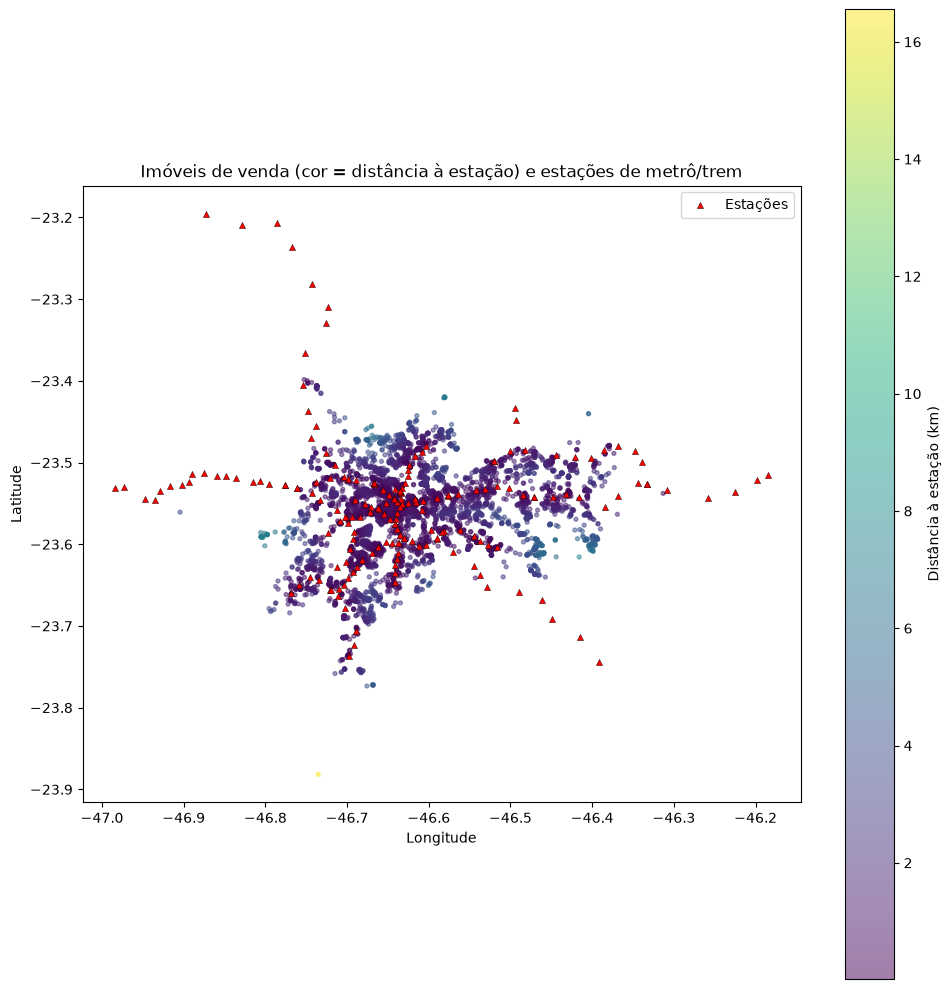

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Pontos dos imóveis, coloridos pela distância à estação (km)
sc = ax.scatter(
    df_venda["Longitude"], df_venda["Latitude"],
    c=df_venda["distancia_estacao"] / 1000,  # em km
    cmap="viridis", s=8, alpha=0.5
)

# Sobrepõe as estações em vermelho (converte de volta pra lat/long pra plotar)
estacoes_latlon = estacoes.to_crs(epsg=4326)
ax.scatter(
    estacoes_latlon.geometry.x, estacoes_latlon.geometry.y,
    c="red", s=20, marker="^", label="Estações", edgecolors="black", linewidths=0.3
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Imóveis de venda (cor = distância à estação) e estações de metrô/trem")
ax.legend()
plt.colorbar(sc, label="Distância à estação (km)")
ax.set_aspect("equal")  # proporção geográfica correta
plt.tight_layout()
plt.show()

In [28]:
# Acha o imóvel mais ao sul e distante — o ponto amarelo do mapa
suspeito = df_venda[
    (df_venda["Latitude"] < -23.85) &
    (df_venda["Longitude"].between(-46.8, -46.7))
]
print(suspeito[["District", "Latitude", "Longitude", "Size", "Price", "distancia_estacao"]].to_string())

                      District  Latitude  Longitude  Size   Price  distancia_estacao
7987  Raposo Tavares/São Paulo -23.88175 -46.735355    48  170000       16559.989081


In [29]:
# Revisa todos os imóveis ainda acima de 8 km — candidatos a coordenada errada
suspeitos = df_venda[df_venda["distancia_estacao"] > 8_000]
print(f"Imóveis de venda > 8 km: {len(suspeitos)}")
print(suspeitos[["District", "Latitude", "Longitude", "distancia_estacao"]]
      .sort_values("distancia_estacao", ascending=False).to_string())

# Mesma checagem no aluguel
suspeitos_a = df_aluguel[df_aluguel["distancia_estacao"] > 8_000]
print(f"\nImóveis de aluguel > 8 km: {len(suspeitos_a)}")
print(suspeitos_a[["District", "Latitude", "Longitude", "distancia_estacao"]]
      .sort_values("distancia_estacao", ascending=False).to_string())

Imóveis de venda > 8 km: 1
                      District  Latitude  Longitude  distancia_estacao
7987  Raposo Tavares/São Paulo -23.88175 -46.735355       16559.989081

Imóveis de aluguel > 8 km: 3
                       District   Latitude  Longitude  distancia_estacao
4673         Perdizes/São Paulo -23.420197 -46.941255       11667.307314
10210  Raposo Tavares/São Paulo -23.624717 -46.955069        8866.025632
2770         Tremembé/São Paulo -23.394787 -46.675994        8024.812752


### Remoção final — coordenadas inconsistentes com o bairro

A inspeção do mapa revelou imóveis remanescentes acima de 8 km da estação. Critério:
manter quando o bairro declarado é de borda (coerente com a distância), remover quando
um bairro central/bem servido aparece longe de estação (coordenada contradiz o bairro).

- **Removidos (2):** Raposo Tavares (venda, 16,5 km — coordenada no extremo sul,
  bairro é zona oeste) e Perdizes (aluguel, 11,7 km — bairro central, coordenada no
  noroeste). Erros de dígito na latitude/longitude.
- **Mantidos:** Tremembé (8,0 km, extremo norte real) e Raposo Tavares (aluguel,
  8,9 km, ponta oeste real na divisa com Cotia) — bairros de borda, distância legítima.

In [30]:
# Remove os dois imóveis com coordenada inconsistente com o bairro (índices identificados)
df_venda   = df_venda.drop(index=7987)
df_aluguel = df_aluguel.drop(index=4673)

print("Venda:  ", len(df_venda), "imóveis")
print("Aluguel:", len(df_aluguel), "imóveis")

# describe final da distância — agora deve estar plenamente são
print("\n=== Distância à estação — venda (final) ===")
print(df_venda["distancia_estacao"].describe())

Venda:   5936 imóveis
Aluguel: 6687 imóveis

=== Distância à estação — venda (final) ===
count    5936.000000
mean     1510.971086
std      1221.063790
min        18.450136
25%       575.181706
50%      1153.538874
75%      2100.801624
max      7469.255164
Name: distancia_estacao, dtype: float64


### Distância à estação — feature consolidada

Após a limpeza completa de coordenadas (corrompidas + fora de escopo + inconsistentes
com o bairro), a feature `distancia_estacao` está confiável:

| Estatística | Valor |
|-------------|-------|
| mínimo | 18 m |
| mediana | 1.154 m |
| média | 1.511 m |
| 75% | 2.101 m |
| máximo | 7.469 m |

Trajetória da limpeza: o máximo saiu de 2.421 km (coordenada em Belém) → 16,5 km
(Raposo Tavares com dígito trocado) → 7,5 km (imóvel legítimo de borda). A base de
venda foi de 6.014 → 5.936 imóveis; aluguel 6.745 → 6.687. A distribuição reflete a
cobertura real de transporte sobre trilhos em São Paulo: densa no centro expandido,
esparsa nas bordas sul e leste. Feature pronta para entrar no modelo.

## 12. Persistência da base com enriquecimento espacial (Bloco 1)

Encerrado o Bloco 1 da Fase 3, salvamos a base limpa e enriquecida como novo artefato.
Em relação ao `imoveis_tratados.parquet` (saída do notebook 01), esta versão:
- removeu imóveis fora de escopo (Medeiros/Jundiaí) e com coordenadas corrompidas ou
  inconsistentes com o bairro (venda 6.014 → 5.936; aluguel 6.745 → 6.687);
- adicionou a feature `distancia_estacao` (distância em metros à estação de
  metrô/trem mais próxima operante em abril/2019).

Salvamos venda e aluguel já separados, pois a limpeza e o enriquecimento foram feitos
sobre cada base. Este artefato é o ponto de partida para a remodelagem (novo baseline
+ distância).

In [31]:
import os
os.makedirs("data/processed", exist_ok=True)

# Salva as duas bases limpas e enriquecidas
df_venda.to_parquet("data/processed/venda_espacial.parquet", index=True)
df_aluguel.to_parquet("data/processed/aluguel_espacial.parquet", index=True)

print("Bases salvas:")
print(f"  venda_espacial.parquet   — {df_venda.shape}")
print(f"  aluguel_espacial.parquet — {df_aluguel.shape}")
print(f"  Colunas: {list(df_venda.columns)}")

Bases salvas:
  venda_espacial.parquet   — (5936, 17)
  aluguel_espacial.parquet — (6687, 17)
  Colunas: ['Price', 'Condo', 'Size', 'Rooms', 'Toilets', 'Suites', 'Parking', 'Elevator', 'Furnished', 'Swimming Pool', 'New', 'District', 'Negotiation Type', 'Property Type', 'Latitude', 'Longitude', 'distancia_estacao']
